# VQC Based on IQC:AIL

## Imports

In [1]:
import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit,Parameter
from qiskit.compiler import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, visualize_transition, plot_bloch_vector
from qiskit.circuit.library import UnitaryGate,Initialize
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix

import pennylane as qml
from pennylane import numpy as pnp
import qutip
from toqito import state_props

import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger
import math

from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold,train_test_split, KFold
from sklearn.multiclass import OneVsRestClassifier
from sklearn.utils.multiclass import unique_labels
from sklearn.utils.validation import check_array, check_is_fitted
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn import preprocessing
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, make_scorer, roc_auc_score, classification_report

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

import pandas as pd


## Base de Dados

In [ ]:
#Gerando o dataset
bc = fetch_ucirepo(id=17)
# data (as pandas dataframes) 
X_bc = bc.data.features 
X_bc = X_bc.values
y_bc = bc.data.targets
y_bc = y_bc.values

#Parâmetros
RANDOM_SEED = 1
LEARNING_RATE = 0.01
N_FEATURES = len(X_bc[0])
N_SAMPLES = len(X_bc)
N_PRINTINGS = N_SAMPLES//10
N_QUBITS=math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
weights=np.full(N_FEATURES,1)
QUBITS=[i for i in range(N_QUBITS)]
N_SHOTS=2048
N_ITER=200

## Tratamento do Dataset

In [ ]:
def normalize_iqc_ail(data, normalize_col=False, normalize_lin=False):
    if normalize_col:
        scaler = MinMaxScaler() #Normaliza a coluna entre [0,1]
        scaler.fit(data)
        data = scaler.transform(data)
        '''
        Perceba que normalizando apenas a coluna, podemos ter amplitudes dos estados em que a norma do estado não fosse igual a 1. Para resolvermos isso, devemos
        normalizar as linhas entre si

        '''
        data = preprocessing.normalize(data,axis=1,norm='l2')
    if normalize_lin:
        data = preprocessing.normalize(data,axis=1,norm='l2') #Normaliza a linha entre [-1,1]
    return data
    
X_bc_iqc_ail_coluna=normalize_iqc_ail(X_bc, normalize_col=True, normalize_lin=False)
X_bc_iqc_ail_linha=normalize_iqc_ail(X_bc,normalize_col=False,normalize_lin=True)

#### Boxplot IQC:AIL Column Normalized

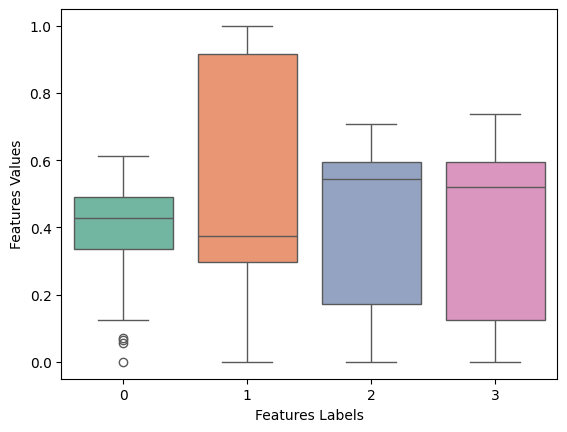

In [4]:
fig, ax = plt.subplots()
sns.boxplot(X_bc_iqc_ail_coluna, palette="Set2",ax=ax)
ax.set_xlabel('Features Labels')
ax.set_ylabel('Features Values')
plt.savefig('boxplot_bc_iqc_ail_coluna.svg')

#### Boxplot IQC:AIL Line Normalized

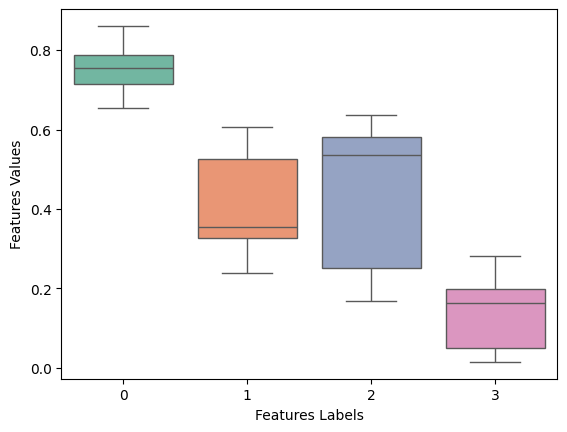

In [ ]:
fig, ax = plt.subplots()
sns.boxplot(X_bc_iqc_ail_linha, palette="Set2",ax=ax)
ax.set_xlabel('Features Labels')
ax.set_ylabel('Features Values')
plt.savefig('boxplot_bc_iqc_ail_linha.svg')

## Função que gera o Quantum Circuit

In [ ]:
def blochvector(rho_cog,matriz_pauli_x,matriz_pauli_y,matriz_pauli_z):
    x_bloch = np.trace(matriz_pauli_x@rho_cog.data)
    y_bloch = np.trace(matriz_pauli_y@rho_cog.data)
    z_bloch = np.trace(matriz_pauli_z@rho_cog.data)
    return [x_bloch,y_bloch,z_bloch]
    
#Executar o circuito
def run_qasm_counts(qc, shots=N_SHOTS):
    qc.measure_all()
    qasm_simulator = Aer.get_backend("qasm_simulator")
    job = qasm_simulator.run(qc, shots=shots)
    result = job.result()
    return result.get_counts()

def cirq_iqc_ail(data,contador,w=weights,qubits=QUBITS, N_qubits=N_QUBITS,N_atributos=N_FEATURES,printar_cirq=False):

    X_blobs_new=list(data)
    if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
        for k in range(2**(N_qubits-1) - N_atributos):
            w=np.append(w,0)
            X_blobs_new=np.append(X_blobs_new,0)
        sigmaE=np.diag(w)
    else:
        sigmaE=np.diag(w)
    
    #Podíamos inicializar assim pra facilitar as contas
    '''x=np.random.rand(2**N_atributos)
    w=np.random.rand(2**N_atributos)'''

    # IQC:AIL

    qc = QuantumCircuit(N_qubits)

    qc.initialize(X_blobs_new, range(1,N_qubits))# Inicializaçao do estado inicial. Poderia ser qualquer estado.
    qc.h(0)


    #Montando os sigmas

    matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
    matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
    matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

    sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

    # qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
    qc.unitary(U,qubits)
    if contador==0:
        qc.draw("mpl", filename=f'./mpl_complete_U_bc_{contador}.svg')
    if printar_cirq==True:
        display(qc.draw('mpl')) #display(qc.draw("mpl", filename='./mpl_original.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    #qc.decompose().draw(output="mpl", style="clifford")
    qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
    if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['cx']<=50 and contador%N_PRINTINGS==0:
        qc.draw("mpl", filename=f'./mpl_transpiled{contador}_blobs.svg')

    if printar_cirq==True and dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50:
        print(dict(qc.count_ops()))
        display(qc.draw('mpl')) #display(qc.draw('mpl', filename='./mpl_transpile.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    # Mostrando o vetor de estado 
    sv = Statevector(qc)
    if contador%N_PRINTINGS==0:
        sv.draw("city", filename=f'./state_vector_city{contador}_blobs.svg')
        sv.draw("bloch", filename=f'./state_vector_bloch{contador}_blobs.svg')
        sv.draw("qsphere", filename=f'./state_vector_qsphere{contador}_blobs.svg')
    if printar_cirq==True:
        display(sv.draw("latex"))

    
    counts = run_qasm_counts(qc)
    if contador%N_PRINTINGS==0:
        plot_histogram(counts,filename=f'./histogram_plot_{contador}_blobs.svg')
    rho_cog = partial_trace(sv, qubits[1:])
    if printar_cirq==True:
        print(rho_cog)

    return blochvector(rho_cog,matriz_pauli_x,matriz_pauli_y,matriz_pauli_z)

## Esfera de Bloch do Circuito

In [ ]:
def esfera_bloch_IQC_AIL(X,norma=None,weights=weights,printar_esf=False):
    point_states=[]
    for k in range(0,N_SAMPLES):
        point_states.append(cirq_iqc_ail(X[k],k,w=weights))

    b = qutip.Bloch()
    b.point_default_color=['k']
    b.point_marker=['o']
    b.point_size=[15, 15, 15, 15]
    for k in range(len(point_states)):
        b.add_points(point_states[k])
    b.render()
    if printar_esf==True:
        b.show()

    bb = b.fig
    if norma:
        bb.savefig(f'Bloch_geral_bc_IQC_AIL_{norma}.svg')
    else:
        bb.savefig(f'Bloch_geral_bc_IQC_AIL.svg')

esfera_bloch_IQC_AIL(X_bc_iqc_ail_coluna,'coluna')
esfera_bloch_IQC_AIL(X_bc_iqc_ail_linha,'linha')